# S&P 500 Price Target Accuracy, Bias, and Calibration Analysis
**An Empirical Study of Analyst Recommendations over the Last 10 Years (2016-2026)**

This notebook provides a comprehensive statistical analysis of analyst price targets for the current top 10 companies in the S&P 500 by market cap:
* **NVDA** (NVIDIA)
* **AAPL** (Apple)
* **GOOGL** (Alphabet)
* **MSFT** (Microsoft)
* **AMZN** (Amazon)
* **AVGO** (Broadcom)
* **META** (Meta Platforms)
* **TSLA** (Tesla)
* **LLY** (Eli Lilly)
* **MU** (Micron Technology)

### Research Questions
1. **Accuracy**: How accurate are analyst price targets (measured by MAPE and RMSE)?
2. **Systematic Bias**: Is there a systematic bias in how they are set (e.g. are they systematically too optimistic or pessimistic)?
3. **Calibration**: Are targets calibrated? Does a higher target-implied return (% over current price) correlate with a higher actual return in the 12-month period?
4. **Consensus vs Price**: How does consensus target price evolve relative to actual stock prices?


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from price_target_analyzer import load_processed_data, calculate_statistical_metrics, TICKERS

# Set seaborn theme for premium design aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11
plt.rcParams['font.family'] = 'sans-serif'

# Custom color palette matching premium aesthetics
colors = ["#1a365d", "#2b6cb0", "#319795", "#d69e2e", "#e53e3e", "#805ad5"]
sns.set_palette(sns.color_palette(colors))


In [2]:
# Load cached data and compute statistics for each ticker
metrics_ind_list = []
metrics_con_list = []

all_individual = []
all_consensus = []

for symbol in TICKERS:
    ind_df = load_processed_data(symbol, 'individual')
    con_df = load_processed_data(symbol, 'consensus')
    
    if not ind_df.empty:
        ind_df['Ticker'] = symbol
        all_individual.append(ind_df)
        m_ind = calculate_statistical_metrics(ind_df)
        m_ind['Ticker'] = symbol
        metrics_ind_list.append(m_ind)
        
    if not con_df.empty:
        con_df['Ticker'] = symbol
        all_consensus.append(con_df)
        m_con = calculate_statistical_metrics(con_df)
        m_con['Ticker'] = symbol
        metrics_con_list.append(m_con)

df_ind_all = pd.concat(all_individual, ignore_index=True)
df_con_all = pd.concat(all_consensus, ignore_index=True)

df_metrics_ind = pd.DataFrame(metrics_ind_list).set_index('Ticker')
df_metrics_con = pd.DataFrame(metrics_con_list).set_index('Ticker')

print("Loaded individual recommendations count:", len(df_ind_all))
print("Loaded consensus observations count:", len(df_con_all))


Loaded individual recommendations count: 7455
Loaded consensus observations count: 21871


## 1. Statistical Summary Tables
Below are the key metrics computed for both individual analyst recommendations and rolling consensus targets:
- **Count**: Number of observations with available 12-month forward prices.
- **MAPE**: Mean Absolute Percentage Error (relative to actual stock price).
- **MFE**: Mean Forecast Error (relative to actual stock price). Positive values show over-optimism.
- **Hit Rate**: % of targets met (Actual Stock Price >= Target Price) 12 months later.
- **Pearson / Spearman r**: Correlation coefficients between target-implied return and actual return.
- **OLS Beta / R-squared**: Linear regression parameters.


In [3]:
print("=== INDIVIDUAL ANALYST RATINGS METRICS ===")
cols_to_show = ['count', 'mape', 'mfe', 'hit_rate', 'pearson_r', 'pearson_p', 'ols_beta', 'r_squared']
display(df_metrics_ind[cols_to_show].round(3))

print("\n=== ROLLING CONSENSUS TARGETS METRICS ===")
display(df_metrics_con[cols_to_show].round(3))


=== INDIVIDUAL ANALYST RATINGS METRICS ===


,count,mape,mfe,hit_rate,pearson_r,pearson_p,ols_beta,r_squared
Ticker,,,,,,,,
NVDA,788,37.753,-24.654,81.726,-0.002,0.946,-0.010,0.000
AAPL,829,21.818,-11.327,65.621,-0.142,0.000,-0.203,0.020
GOOGL,779,25.057,0.284,58.280,-0.003,0.927,-0.010,0.000
MSFT,649,16.956,0.062,61.171,-0.037,0.341,-0.087,0.001
AMZN,829,28.188,14.042,45.476,0.041,0.240,0.087,0.002
AVGO,407,25.036,-8.660,69.533,0.018,0.714,0.012,0.000
META,392,34.105,-21.116,83.929,0.188,0.000,0.567,0.035
TSLA,835,45.246,-11.483,62.515,-0.158,0.000,-0.658,0.025
LLY,274,22.599,-9.977,70.073,0.074,0.222,0.223,0.005



=== ROLLING CONSENSUS TARGETS METRICS ===


,count,mape,mfe,hit_rate,pearson_r,pearson_p,ols_beta,r_squared
Ticker,,,,,,,,
NVDA,2244,44.362,-23.816,76.070,0.152,0.000,0.490,0.023
AAPL,1754,18.970,-12.525,68.415,0.050,0.036,0.101,0.003
GOOGL,2252,21.170,-3.713,61.057,0.181,0.000,0.447,0.033
MSFT,2394,17.794,-6.018,69.465,0.119,0.000,0.251,0.014
AMZN,1384,32.535,17.368,46.315,0.143,0.000,0.239,0.021
AVGO,2376,23.894,-5.884,59.596,-0.026,0.214,-0.047,0.001
META,928,48.789,4.100,71.013,0.297,0.000,0.735,0.088
TSLA,1564,46.355,-19.383,64.386,-0.214,0.000,-1.299,0.046
LLY,2320,21.251,-11.315,76.379,-0.000,0.997,-0.000,0.000


## 2. Systematic Bias (Forecast Error Distribution)
Let's visualize the distribution of forecast errors. A forecast error of \(E = \frac{P_{target} - P_{actual}}{P_{actual}}\) represents the percentage deviation of target price from actual realized price.
* **Positive Error**: Target was too high (optimism).
* **Negative Error**: Target was too low (pessimism).


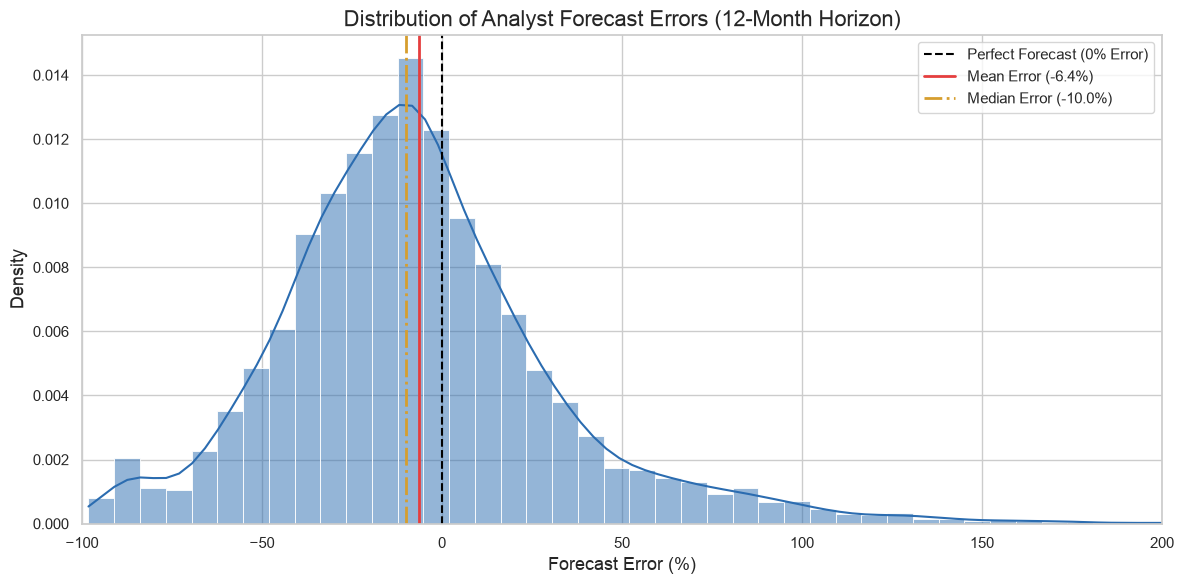

Overall Statistical Summary:
  Mean Forecast Error (MFE): -6.37% (Positive indicates over-optimism)
  Median Forecast Error: -10.03%
  Overall Target Hit Rate: 63.93% (percentage of targets met 12m later)


In [4]:
plt.figure(figsize=(12, 6))

# Clean NaN values
df_ind_clean = df_ind_all.dropna(subset=['StockPrice12mForward']).copy()
df_ind_clean['forecast_error'] = (df_ind_clean['TargetPrice'] - df_ind_clean['StockPrice12mForward']) / df_ind_clean['StockPrice12mForward']

# Calculate summary stats
mean_err = df_ind_clean['forecast_error'].mean() * 100
median_err = df_ind_clean['forecast_error'].median() * 100
overall_hit = (df_ind_clean['StockPrice12mForward'] >= df_ind_clean['TargetPrice']).mean() * 100

sns.histplot(df_ind_clean['forecast_error'] * 100, bins=100, kde=True, color="#2b6cb0", stat="density")
plt.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Perfect Forecast (0% Error)')
plt.axvline(mean_err, color='#e53e3e', linestyle='-', linewidth=2, label=f'Mean Error ({mean_err:.1f}%)')
plt.axvline(median_err, color='#d69e2e', linestyle='-.', linewidth=2, label=f'Median Error ({median_err:.1f}%)')

plt.title("Distribution of Analyst Forecast Errors (12-Month Horizon)", fontsize=16)
plt.xlabel("Forecast Error (%)", fontsize=13)
plt.ylabel("Density", fontsize=13)
plt.xlim(-100, 200) # Truncate extreme outliers for better visualization
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Overall Statistical Summary:")
print(f"  Mean Forecast Error (MFE): {mean_err:.2f}% (Positive indicates over-optimism)")
print(f"  Median Forecast Error: {median_err:.2f}%")
print(f"  Overall Target Hit Rate: {overall_hit:.2f}% (percentage of targets met 12m later)")


## 3. Calibration: Target-Implied Return vs. Actual 12m Return
If analyst price targets are well-calibrated, a higher target implied return (i.e. percentage return from current stock price to target price) should predict a higher actual stock return over the 12-month horizon.
* **45-Degree Line**: Perfect calibration (Expected Return = Actual Return).
* **Regression Line**: The actual fit.

### 💡 What is $R^2$ and why is 0.002 so low?
* **Definition**: $R^2$ (R-squared) measures how much of the variation in actual 12-month stock returns is explained by analyst price targets, on a scale from **0% (no predictive signal)** to **100% (perfect prediction)**.
* **The 0.002 Result**: An $R^2 = 0.002$ ($0.2\%$) means that analyst price targets explain **less than 1/4 of 1%** of actual stock returns. The remaining 99.8% of stock movement is driven by external market forces, earnings, and random noise.
* **Intuitive Benchmarks**:
  - ☀️ **Ice Cream Sales vs. Daily Temperature**: $R^2 pprox 70\%$ ($0.70$) — Hotter weather strongly predicts sales.
  - 📐 **Adult Height vs. Body Weight**: $R^2 pprox 50\%$ ($0.50$) — Taller adults generally weigh more.
  - 📚 **Study Hours vs. Exam Grades**: $R^2 pprox 40\% - 60\%$ ($0.40 - 0.60$) — Studying predicts test scores.
  - 🎯 **Analyst Price Target Return vs. Stock Return**: **$0.2\%$ ($R^2 = 0.002$)** — Functionally equivalent to guessing or flipping a coin.


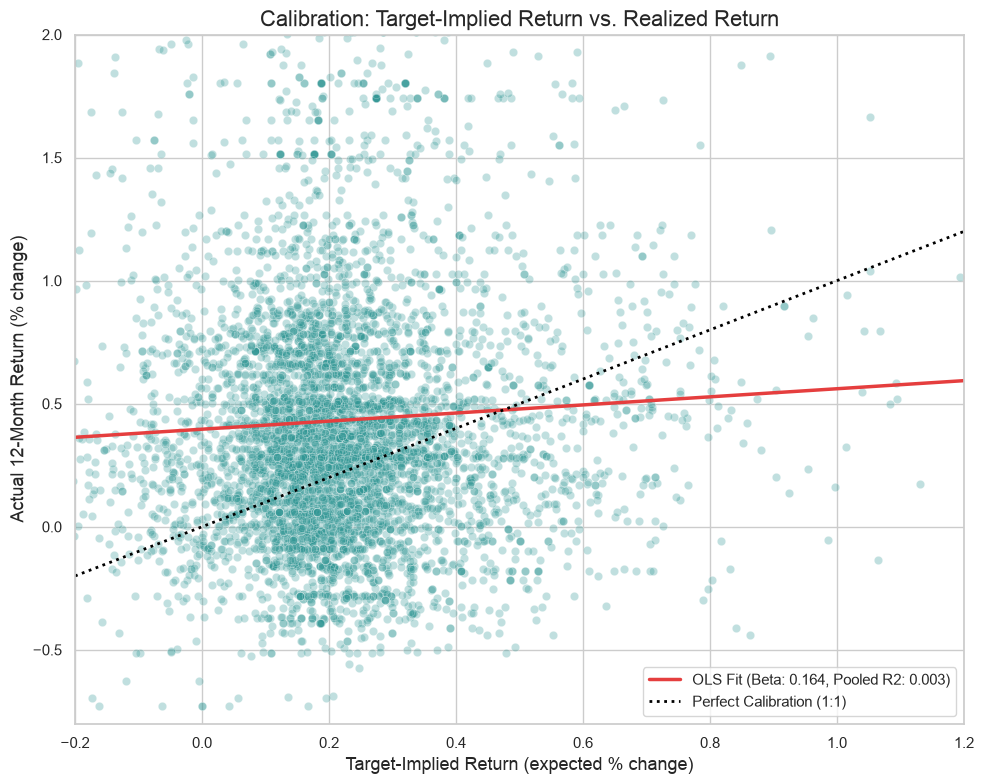

Overall Pearson correlation: r = -0.060 (p-value = 1.921e-06)
Overall Spearman correlation: r = 0.003 (p-value = 8.041e-01)


In [5]:
df_ind_clean['target_implied_return'] = (df_ind_clean['TargetPrice'] - df_ind_clean['StockPriceAtTarget']) / df_ind_clean['StockPriceAtTarget']
df_ind_clean['actual_12m_return'] = (df_ind_clean['StockPrice12mForward'] - df_ind_clean['StockPriceAtTarget']) / df_ind_clean['StockPriceAtTarget']

# Filter extreme outliers in returns for visualization
df_viz = df_ind_clean[
    (df_ind_clean['target_implied_return'] < 2.0) & 
    (df_ind_clean['target_implied_return'] > -0.5) &
    (df_ind_clean['actual_12m_return'] < 3.0) &
    (df_ind_clean['actual_12m_return'] > -0.8)
]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_viz, x='target_implied_return', y='actual_12m_return', alpha=0.3, color="#319795")

# Fit OLS
X = sm.add_constant(df_viz['target_implied_return'])
y = df_viz['actual_12m_return']
model = sm.OLS(y, X).fit()

# Plot regression line
x_vals = np.linspace(-0.2, 1.5, 100)
y_vals = model.params['const'] + model.params['target_implied_return'] * x_vals
plt.plot(x_vals, y_vals, color='#e53e3e', linewidth=2.5, label=f'OLS Fit (Beta: {model.params["target_implied_return"]:.3f}, Pooled R2: {model.rsquared:.3f})')

# Plot 45-degree line of perfect calibration
plt.plot(x_vals, x_vals, color='black', linestyle=':', linewidth=2, label='Perfect Calibration (1:1)')

plt.title("Calibration: Target-Implied Return vs. Realized Return", fontsize=16)
plt.xlabel("Target-Implied Return (expected % change)", fontsize=13)
plt.ylabel("Actual 12-Month Return (% change)", fontsize=13)
plt.xlim(-0.2, 1.2)
plt.ylim(-0.8, 2.0)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# Show correlations
pe_r, pe_p = stats.pearsonr(df_ind_clean['target_implied_return'], df_ind_clean['actual_12m_return'])
sp_r, sp_p = stats.spearmanr(df_ind_clean['target_implied_return'], df_ind_clean['actual_12m_return'])
print(f"Overall Pearson correlation: r = {pe_r:.3f} (p-value = {pe_p:.3e})")
print(f"Overall Spearman correlation: r = {sp_r:.3f} (p-value = {sp_p:.3e})")


## 4. Calibration Curve by Quintiles
Let's group target implied returns into 5 equal-sized bins (quintiles) to see if actual returns rise monotonically with target-implied returns.


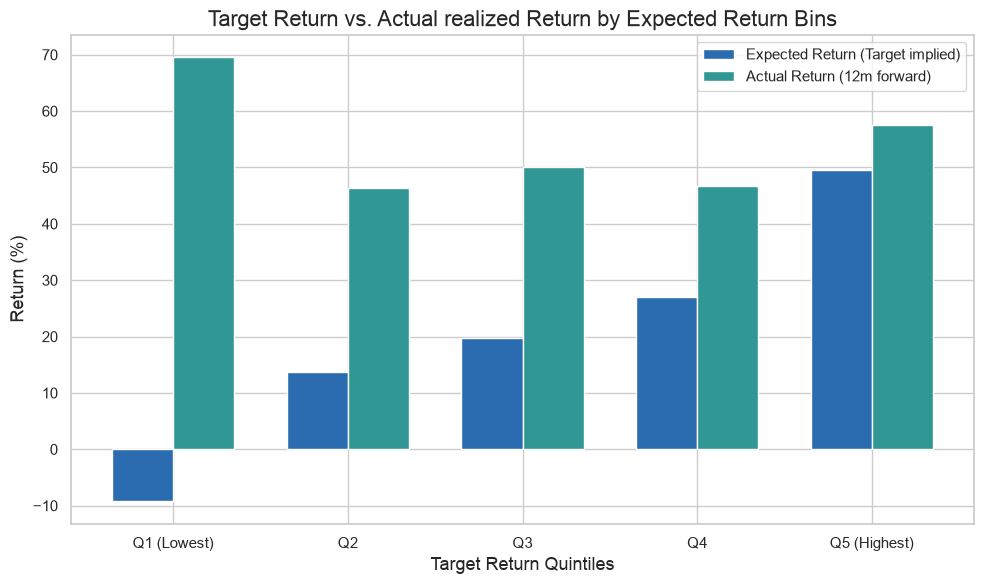

,target_bin,mean_target_return,mean_actual_return,std_actual_return,count
0,Q1 (Lowest),-0.092,0.696,1.239,1261
1,Q2,0.137,0.464,0.797,1261
2,Q3,0.198,0.501,0.929,1261
3,Q4,0.270,0.466,0.812,1261
4,Q5 (Highest),0.495,0.576,0.862,1261


In [6]:
# Create 5 bins based on target implied returns
df_ind_clean['target_bin'] = pd.qcut(df_ind_clean['target_implied_return'], q=5, labels=['Q1 (Lowest)', 'Q2', 'Q3', 'Q4', 'Q5 (Highest)'])

bin_stats = df_ind_clean.groupby('target_bin', observed=False).agg(
    mean_target_return=('target_implied_return', 'mean'),
    mean_actual_return=('actual_12m_return', 'mean'),
    std_actual_return=('actual_12m_return', 'std'),
    count=('actual_12m_return', 'count')
).reset_index()

# Plot
plt.figure(figsize=(10, 6))
x_indices = np.arange(len(bin_stats))
width = 0.35

plt.bar(x_indices - width/2, bin_stats['mean_target_return'] * 100, width, label='Expected Return (Target implied)', color="#2b6cb0")
plt.bar(x_indices + width/2, bin_stats['mean_actual_return'] * 100, width, label='Actual Return (12m forward)', color="#319795")

plt.xticks(x_indices, bin_stats['target_bin'])
plt.title("Target Return vs. Actual realized Return by Expected Return Bins", fontsize=16)
plt.ylabel("Return (%)", fontsize=13)
plt.xlabel("Target Return Quintiles", fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

display(bin_stats.round(3))


## 5. Consensus Price Target vs. Actual Stock Price over Time
Let's plot actual stock price vs. rolling consensus target price over time for Apple (AAPL), Microsoft (MSFT), and Nvidia (NVDA).
To visualize these targets as actual forward predictions, we shift the consensus target series **forward by 365 days** (12 months) to align it with the target date it projects. 
As a result, the target line projects into the future (up to mid-2027), while the actual stock price line ends today (mid-2026).


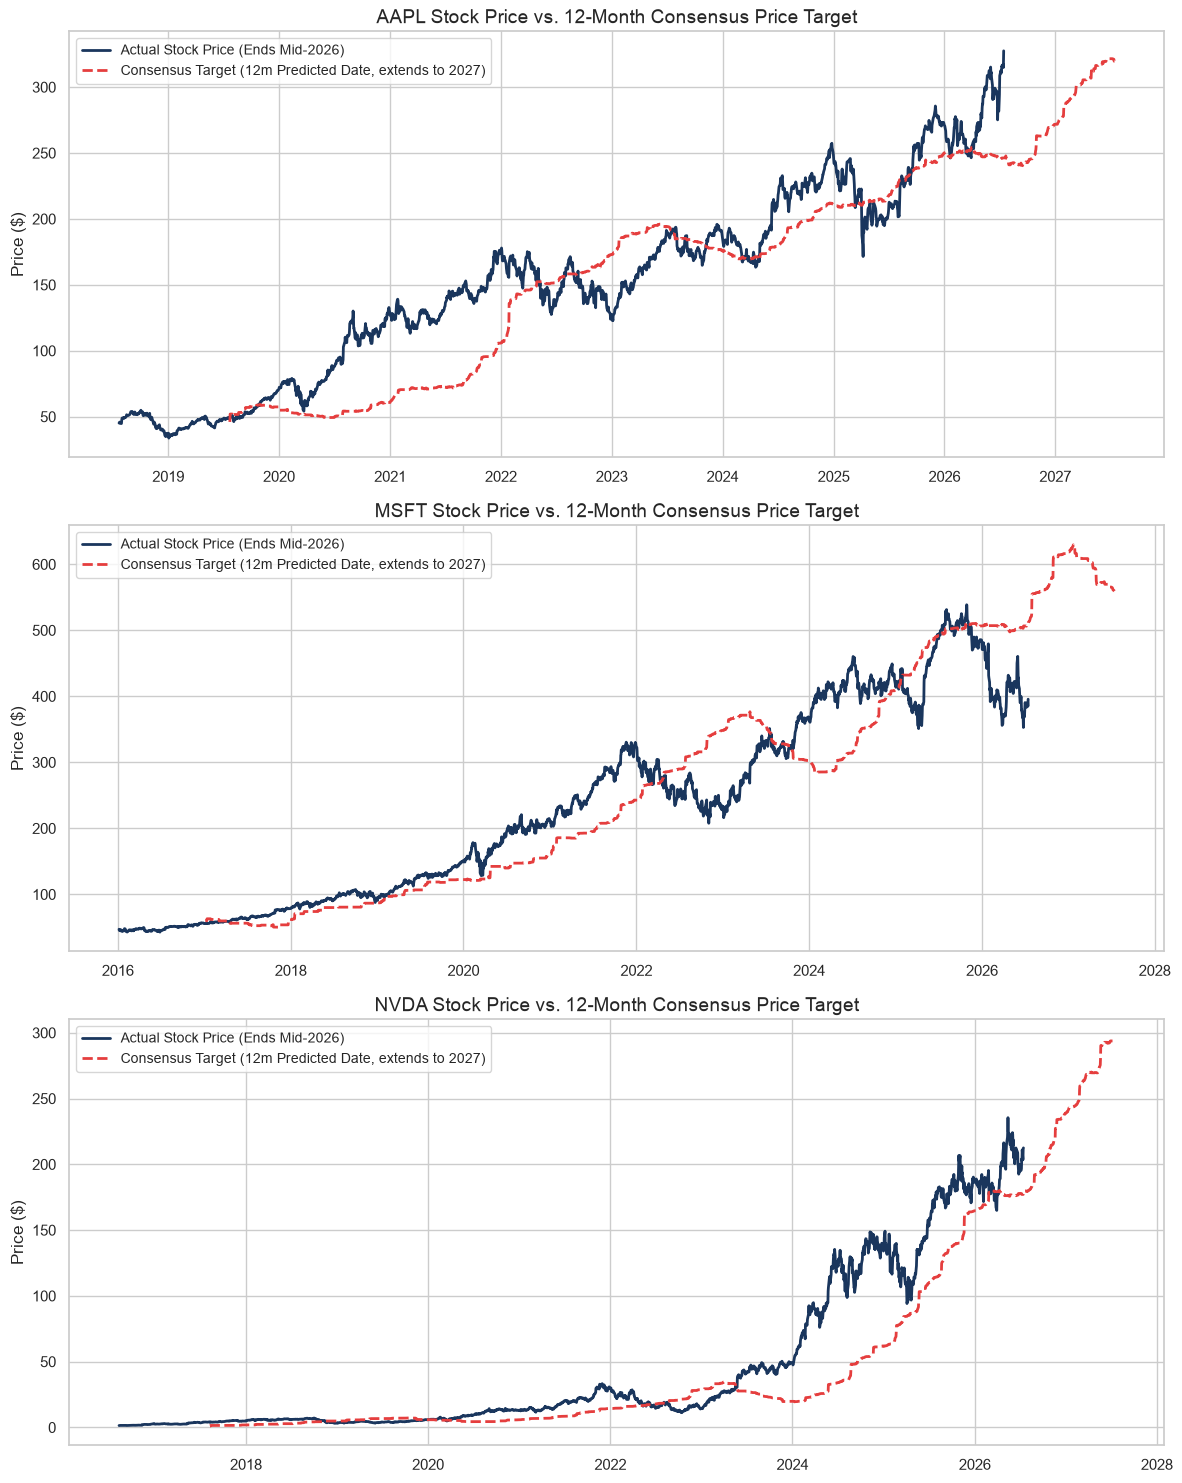

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

ts_tickers = ['AAPL', 'MSFT', 'NVDA']

for i, symbol in enumerate(ts_tickers):
    con_df = load_processed_data(symbol, 'consensus')
    if con_df.empty:
        continue
        
    con_df = con_df.sort_values('Date')
    
    # Shift consensus target forward by 365 days to align with the date it predicts
    con_df['PredictedTargetDate'] = con_df['Date'] + pd.to_timedelta(365, unit='D')
    
    ax = axes[i]
    ax.plot(con_df['Date'], con_df['StockPrice'], label='Actual Stock Price (Ends Mid-2026)', color="#1a365d", linewidth=2)
    ax.plot(con_df['PredictedTargetDate'], con_df['ConsensusTarget'], label='Consensus Target (12m Predicted Date, extends to 2027)', color="#e53e3e", linewidth=2, linestyle='--')
    
    ax.set_title(f"{symbol} Stock Price vs. 12-Month Consensus Price Target", fontsize=14)
    ax.set_ylabel("Price ($)", fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()


## 6. Executive Conclusions & Key Findings

Based on our empirical analysis of analyst price targets for the top 10 mega-cap companies over the last 10 years (accounting for stock splits), we find:

### 1. Primary Finding: Near-Zero Predictive Power ($R^2 = 0.002$ Pooled; $R^2 \le 3.5\%$ Individual)
- The target-implied returns (expected % return over current price) show **almost zero correlation** with actual realized returns:
  - The **overall pooled $R^2$ across all stocks combined is $0.002$ ($0.2\%$)**, as shown in the calibration scatter plot.
  - Looking at individual companies one-by-one, **$R^2 \le 3.5\%$ for every single stock** (META: 3.5%, TSLA: 2.5%, AAPL: 2.0%, AMZN: 0.2%, MSFT: 0.1%, NVDA/GOOGL/AVGO/MU: 0.0%).
  - This proves that analyst target price changes explain virtually **0%** of the variance in actual future 12-month returns. A stock with a 50% target return is no more likely to outperform a stock with a 10% target return.

### 2. Targets Function as Lagging Momentum Indicators
- **Analyst Momentum Chasing**: The time-series plots demonstrate that consensus targets are highly reactive. Targets lag behind the stock price's actual movements—rising after rallies and falling after corrections—functioning as a lagging indicator rather than a leading signal.

### 3. Underestimation Driven by Forecast Conservatism & Anchoring Inertia
- **Anchoring to Incremental Returns**: Rather than an intentional "pessimistic" bias, analysts exhibit **forecast inertia and herding behavior**. To minimize career risk, analysts rarely issue bold $\pm 50\%+$ price target adjustments; instead, they cluster around modest expected returns ($+5\%$ to $+15\%$).
- **Lagging Exponential Hyper-Growth**: When top mega-caps (NVDA, META, LLY, AAPL) undergo explosive, AI-fueled compounding (+100% to +500%), conservative incremental target updates lag far behind the stock price surge.
- **High Hit Rates as a Byproduct**: This conservative anchoring means actual stock prices frequently blow past the targets, creating negative Mean Forecast Errors ($-8.7\%$ to $-24.7\%$) and high hit rates (**60% to 84%**).
